In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

D = "/home/robotserver/wj/go1_antalgic/scripts/rsl_rl/logs/unitree_go1_antalgic/2026_09_03_19_47_35_phase2_s42_P2-AT-001/obs_debug"

action = pd.read_csv(f"{D}/action.csv")
raw = pd.read_csv(f"{D}/obs_raw.csv")
# norm = pd.read_csv(f"{D}/obs_norm.csv")

In [3]:
print("raw :", raw.shape)
# print("norm :", norm.shape)
print("action :", action.shape)

print(raw.columns.tolist())

raw : (1440000, 59)
action : (1440000, 14)
['step', 'env_id', 'ang_vel_x', 'ang_vel_y', 'ang_vel_z', 'gravity_x', 'gravity_y', 'gravity_z', 'cmd_vx', 'cmd_vy', 'cmd_wz', 'jpos_hip_FL', 'jpos_hip_FR', 'jpos_hip_RL', 'jpos_hip_RR', 'jpos_thigh_FL', 'jpos_thigh_FR', 'jpos_thigh_RL', 'jpos_thigh_RR', 'jpos_calf_FL', 'jpos_calf_FR', 'jpos_calf_RL', 'jpos_calf_RR', 'jvel_hip_FL', 'jvel_hip_FR', 'jvel_hip_RL', 'jvel_hip_RR', 'jvel_thigh_FL', 'jvel_thigh_FR', 'jvel_thigh_RL', 'jvel_thigh_RR', 'jvel_calf_FL', 'jvel_calf_FR', 'jvel_calf_RL', 'jvel_calf_RR', 'act_hip_FL', 'act_hip_FR', 'act_hip_RL', 'act_hip_RR', 'act_thigh_FL', 'act_thigh_FR', 'act_thigh_RL', 'act_thigh_RR', 'act_calf_FL', 'act_calf_FR', 'act_calf_RL', 'act_calf_RR', 'onehot_FL', 'onehot_FR', 'onehot_RL', 'onehot_RR', 'splint_L', 'lin_vel_x', 'lin_vel_y', 'lin_vel_z', 'calf_q_FL', 'calf_q_FR', 'calf_q_RL', 'calf_q_RR']


In [5]:
obs_cols = [
    "step",
    "env_id",
    "splint_L",
    "lin_vel_x",
    "lin_vel_y",
    "lin_vel_z",
]

obs = raw[obs_cols].copy()
obs.head(30)

,step,env_id,splint_L,lin_vel_x,lin_vel_y,lin_vel_z
0,0,102,0.000000,0.000000,0.000000,0.000000
1,0,307,0.000000,0.000000,0.000000,0.000000
2,0,512,0.000000,0.000000,0.000000,0.000000
3,0,716,0.000000,0.000000,0.000000,0.000000
4,0,921,0.000000,0.000000,0.000000,0.000000
5,0,1126,0.351267,0.000000,0.000000,0.000000
6,0,1331,0.331862,0.000000,0.000000,0.000000
7,0,1536,0.376402,0.000000,0.000000,0.000000
8,0,1740,0.416955,0.000000,0.000000,0.000000
9,0,1945,0.409652,0.000000,0.000000,0.000000


In [6]:
same_step = np.array_equal(
    action["step"].to_numpy(),
    obs["step"].to_numpy()
)

same_env = np.array_equal(
    action["env_id"].to_numpy(),
    obs["env_id"].to_numpy()
)


print(f"step sequence: {same_step}")
print(f"env_id sequence: {same_env}")

step sequence: True
env_id sequence: True


In [7]:
# 결측치 / 중복 / 데이터 범위 확인

print("[결측치]")
display(obs.isna().sum())

print("\n[action 결측치]")
display(action.isna().sum())

print("\nstep 범위")
print(obs["step"].min(), "~", obs["step"].max())

print("\nenv id")
print(sorted(obs["env_id"].unique()))

print("\n전체 row 수")
print(len(obs))

[결측치]


step         0
env_id       0
splint_L     0
lin_vel_x    0
lin_vel_y    0
lin_vel_z    0
dtype: int64


[action 결측치]


step          0
env_id        0
a_hip_FL      0
a_hip_FR      0
a_hip_RL      0
a_hip_RR      0
a_thigh_FL    0
a_thigh_FR    0
a_thigh_RL    0
a_thigh_RR    0
a_calf_FL     0
a_calf_FR     0
a_calf_RL     0
a_calf_RR     0
dtype: int64


step 범위
0 ~ 143999

env id
[np.int64(102), np.int64(307), np.int64(512), np.int64(716), np.int64(921), np.int64(1126), np.int64(1331), np.int64(1536), np.int64(1740), np.int64(1945)]

전체 row 수
1440000


In [8]:
envs_per_step = obs.groupby("step").size()
display(envs_per_step.describe())

count    144000.0
mean         10.0
std           0.0
min          10.0
25%          10.0
50%          10.0
75%          10.0
max          10.0
dtype: float64

In [9]:
# velocity statistic
vel_cols = [
    "lin_vel_x",
    "lin_vel_y",
    "lin_vel_z",
]

V = obs[vel_cols].copy()
print(type(V))
V.describe()

<class 'pandas.DataFrame'>


,lin_vel_x,lin_vel_y,lin_vel_z
count,1.440000e+06,1.440000e+06,1.440000e+06
mean,5.162062e-01,7.946365e-04,-1.585307e-03
std,2.636715e-01,1.600218e-01,7.030287e-02
min,-7.031690e-01,-1.154910e+00,-7.353730e-01
25%,2.987690e-01,-1.282740e-01,-4.387430e-02
50%,5.097750e-01,2.084485e-03,-2.355095e-03
75%,7.390130e-01,1.278620e-01,3.973158e-02
max,1.657940e+00,1.197870e+00,1.099150e+00


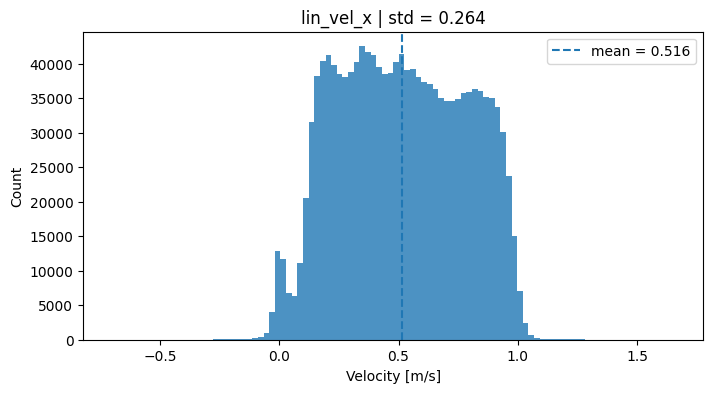

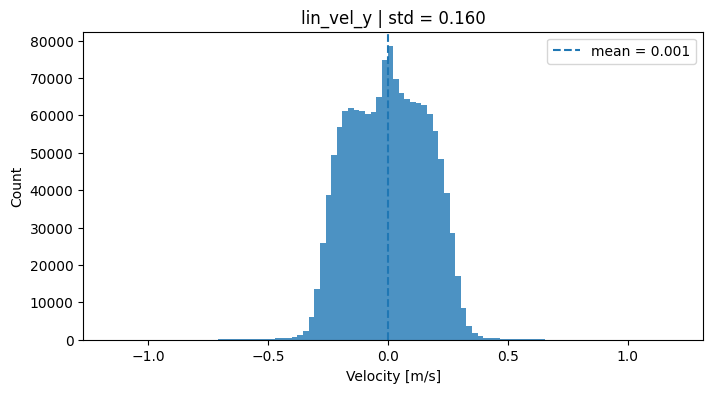

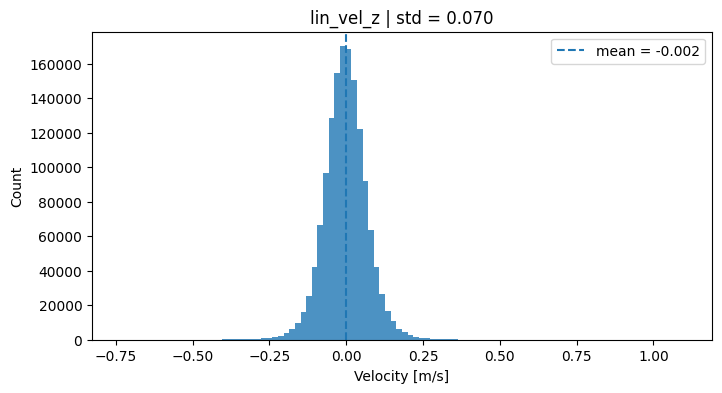

In [10]:
# Velocity 분포 시각화

for col in vel_cols:

    plt.figure(figsize=(8, 4))

    plt.hist(
        V[col],
        bins=100,
        alpha=0.8
    )

    plt.axvline(
        V[col].mean(),
        linestyle="--",
        label=f"mean = {V[col].mean():.3f}"
    )

    plt.title(
        f"{col} | std = {V[col].std(ddof=0):.3f}"
    )

    plt.xlabel("Velocity [m/s]")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

In [11]:
# reset frame 확인

reset_mask = (V == 0.0).all(axis=1)
print(f"reset frame 수: {reset_mask.sum()}")
print(f"전체 대비 비율: {reset_mask.mean()}")

reset frame 수: 1502
전체 대비 비율: 0.0010430555555555555


In [12]:
V_clean = V.loc[~reset_mask].copy()

print("원본 :", len(V))
print("제거 후:", len(V_clean))

원본 : 1440000
제거 후: 1438498


In [13]:
# 환경 reset 때문에 인위적으로 생긴 상태

before = V.agg(["mean", "std"])
after = V_clean.agg(["mean", "std"])

print("[reset 제거 전]")
display(before)

print("[reset 제거 후]")
display(after)

[reset 제거 전]


,lin_vel_x,lin_vel_y,lin_vel_z
mean,0.516206,0.000795,-0.001585
std,0.263672,0.160022,0.070303


[reset 제거 후]


,lin_vel_x,lin_vel_y,lin_vel_z
mean,0.516745,0.000795,-0.001587
std,0.263281,0.160105,0.070340


In [14]:
# Velocity 축별 mean, std, variance

v_mean = V_clean.mean()

# pandas std 기본 ddof=1이므로
# 정규화 통계에서는 모집단 std를 쓰기 위해 ddof=0
v_std = V_clean.std(ddof=0)
v_var = V_clean.var(ddof=0)

vel_stats = pd.DataFrame({
    "mean": v_mean,
    "std": v_std,
    "variance": v_var,
})

display(vel_stats)

,mean,std,variance
lin_vel_x,0.516745,0.263281,0.069317
lin_vel_y,0.000795,0.160105,0.025634
lin_vel_z,-0.001587,0.070340,0.004948


In [ ]:
# Normalize velocity: pooled std

v_pooled_std = np.sqrt(v_var.mean())
print("축별 std:")
display(v_std)

print(f"\nVelocity pooled std = {v_pooled_std:.4f}")

축별 std:


lin_vel_x    0.263281
lin_vel_y    0.160105
lin_vel_z    0.070340
dtype: float64


Velocity pooled std = 0.1825


In [31]:

V_z = (
    V_clean - v_mean
) / v_pooled_std

print("정규화 후 축별 평균")
display(V_z.mean())

print("정규화 후 축별 std")
display(V_z.std(ddof=0))

print(
    "\n전체 head의 평균 squared value =",
    np.mean(V_z.to_numpy() ** 2)
)

정규화 후 축별 평균


lin_vel_x    3.970549e-16
lin_vel_y   -7.587036e-18
lin_vel_z    2.529012e-18
dtype: float64

정규화 후 축별 std


lin_vel_x    1.442783
lin_vel_y    0.877380
lin_vel_z    0.385462
dtype: float64


전체 head의 평균 squared value = 1.0


In [17]:
# --------------------------------------------------
# STEP 10. Splint Length 분리
# --------------------------------------------------

L = obs["splint_L"]

injured_mask = L > 0

L_injured = L.loc[injured_mask].copy()

print("전체 row :", len(L))
print("부상 row :", len(L_injured))
print("부상 비율:", injured_mask.mean())

전체 row : 1440000
부상 row : 720000
부상 비율: 0.5


In [18]:
injured_mask = L > 0

In [21]:
# --------------------------------------------------
# STEP 11. Splint Length 기본 통계
# --------------------------------------------------

display(
    L_injured.describe()
)

count    720000.000000
mean          0.390027
std           0.034284
min           0.330389
25%           0.360840
50%           0.390539
75%           0.417958
max           0.449831
Name: splint_L, dtype: float64

In [23]:
# --------------------------------------------------
# STEP 12. L 이론 통계
# --------------------------------------------------

L_min = 0.33
L_max = 0.45

L_mean_theory = (L_min + L_max) / 2

L_std_theory = (
    L_max - L_min
) / np.sqrt(12)

print(f"이론 mean = {L_mean_theory:.6f}")
print(f"이론 std  = {L_std_theory:.6f}")

이론 mean = 0.390000
이론 std  = 0.034641


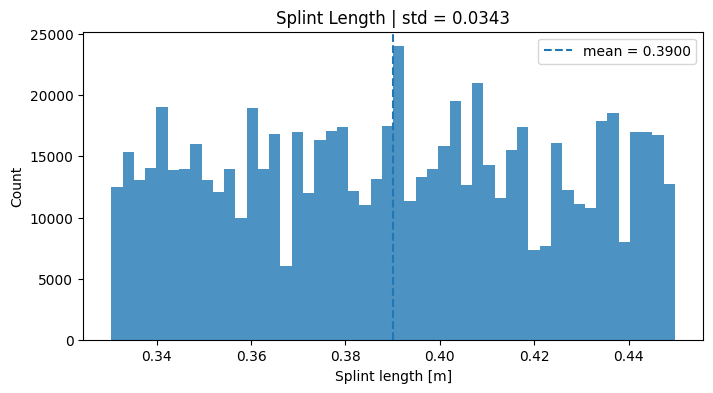

In [22]:
plt.figure(figsize=(8, 4))

plt.hist(
    L_injured,
    bins=50,
    alpha=0.8
)

plt.axvline(
    L_injured.mean(),
    linestyle="--",
    label=f"mean = {L_injured.mean():.4f}"
)

plt.xlabel("Splint length [m]")
plt.ylabel("Count")
plt.title(
    f"Splint Length | std = {L_injured.std(ddof=0):.4f}"
)
plt.legend()
plt.show()

In [32]:
# --------------------------------------------------
# STEP 13. L normalization 검증
# --------------------------------------------------

L_z = (
    L_injured - L_mean_theory
) / L_std_theory

print(
    f"L mean theory = {L_mean_theory}"
)

print(
    f"L std theory = {L_std_theory}"
)

print(
    f"normalized mean = {L_z.mean():.4f}"
)

print(
    f"normalized std  = {L_z.std(ddof=0):.4f}"
)

print(
    f"baseline MSE    = {np.mean(L_z ** 2):.4f}"
)

L mean theory = 0.39
L std theory = 0.034641016151377546
normalized mean = 0.0008
normalized std  = 0.9897
baseline MSE    = 0.9795


In [25]:
# --------------------------------------------------
# STEP 14. Action column 분리
# --------------------------------------------------

action_cols = [
    c for c in action.columns
    if c not in ["step", "env_id"]
]

print("action 차원:", len(action_cols))
print(action_cols)

A_all = action[action_cols].copy()

action 차원: 12
['a_hip_FL', 'a_hip_FR', 'a_hip_RL', 'a_hip_RR', 'a_thigh_FL', 'a_thigh_FR', 'a_thigh_RL', 'a_thigh_RR', 'a_calf_FL', 'a_calf_FR', 'a_calf_RL', 'a_calf_RR']


In [26]:
display(
    A_all.describe().T
)

,count,mean,std,min,25%,50%,75%,max
a_hip_FL,1440000.0,-0.889090,0.404166,-4.94686,-1.142220,-0.908921,-0.657545,4.14909
a_hip_FR,1440000.0,0.890791,0.427693,-3.52831,0.650604,0.904445,1.149280,4.64584
a_hip_RL,1440000.0,-1.357840,0.672251,-5.05287,-1.581050,-1.268740,-0.978649,1.79063
a_hip_RR,1440000.0,1.186326,0.489886,-3.59527,0.897310,1.178480,1.469290,3.97273
a_thigh_FL,1440000.0,-0.851536,0.559619,-4.25186,-1.216330,-0.912365,-0.574232,2.85085
a_thigh_FR,1440000.0,-0.829620,0.523663,-3.87838,-1.184100,-0.883048,-0.546188,3.59910
a_thigh_RL,1440000.0,-1.125768,0.841626,-3.63369,-1.679800,-1.336970,-0.831241,3.18802
a_thigh_RR,1440000.0,-1.219177,0.732142,-4.00405,-1.664470,-1.345840,-0.968749,3.23188
a_calf_FL,1440000.0,2.625757,0.762413,-6.49387,2.084660,2.855360,3.195990,5.69363
a_calf_FR,1440000.0,2.632387,0.744784,-8.40925,2.118720,2.855960,3.187632,5.82995


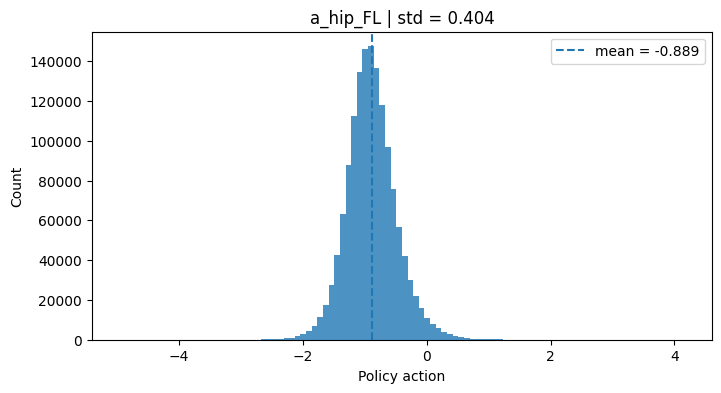

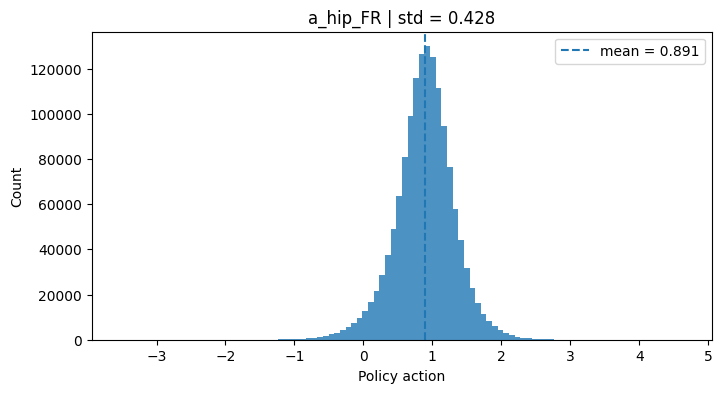

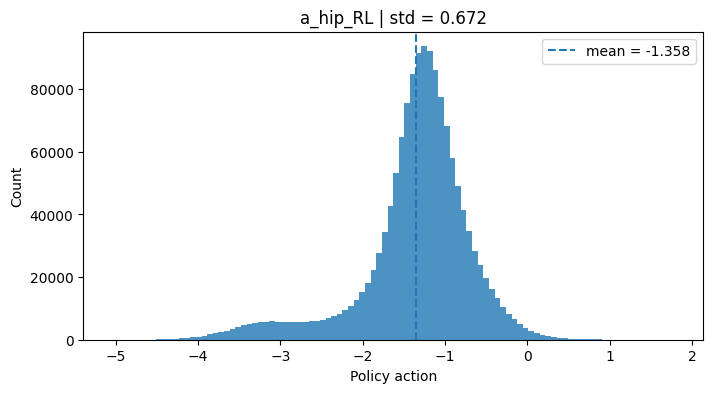

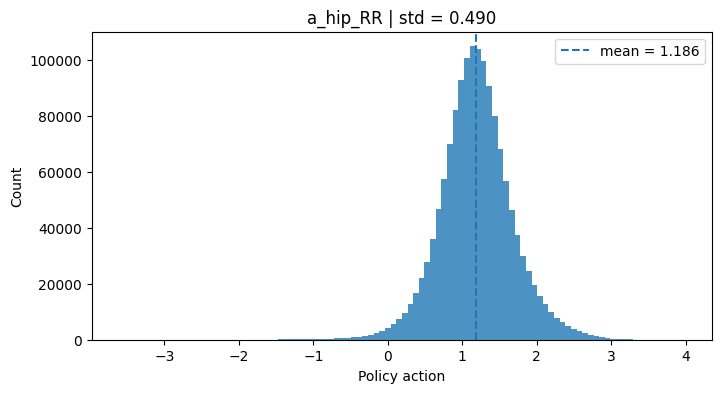

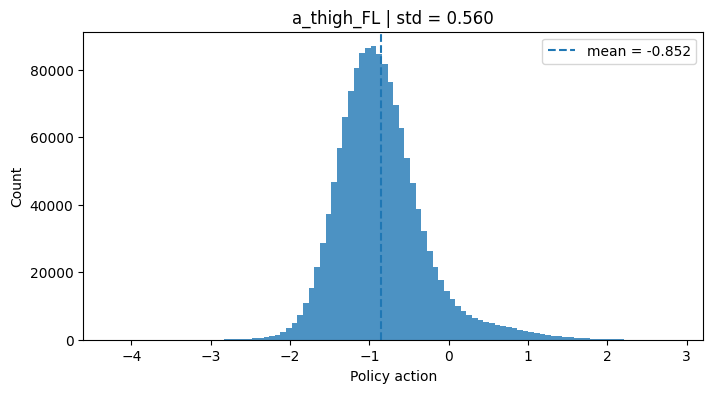

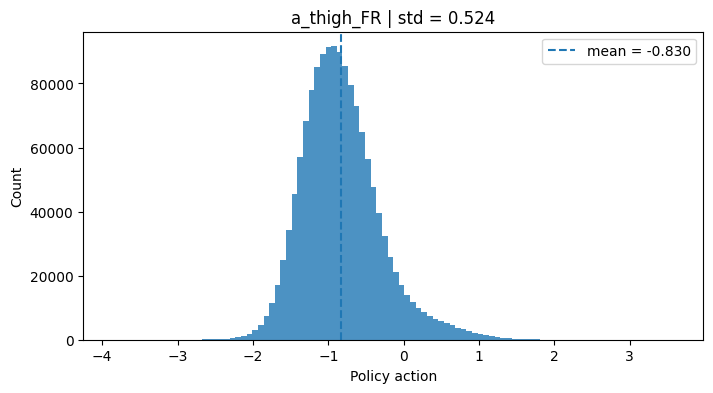

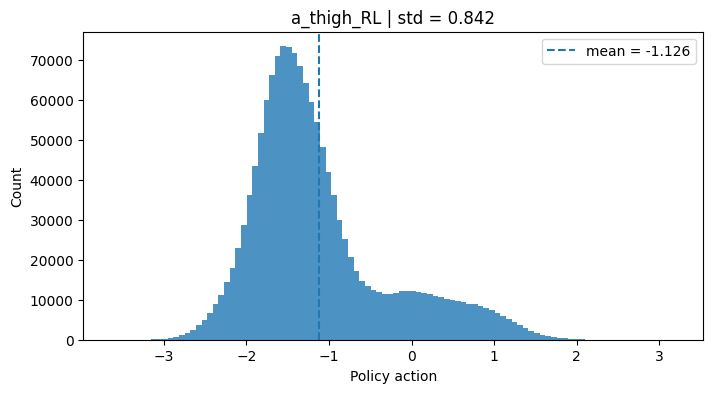

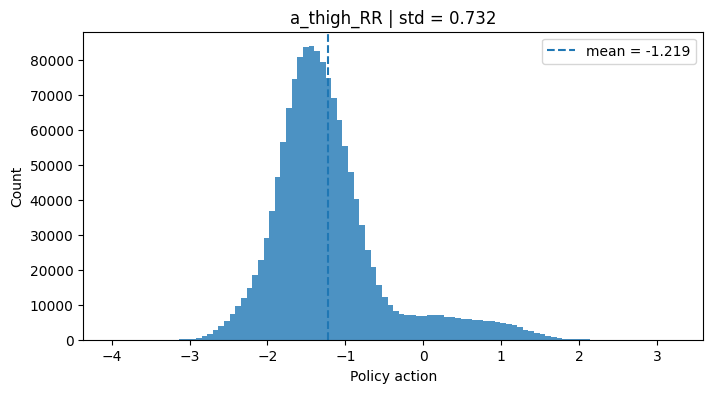

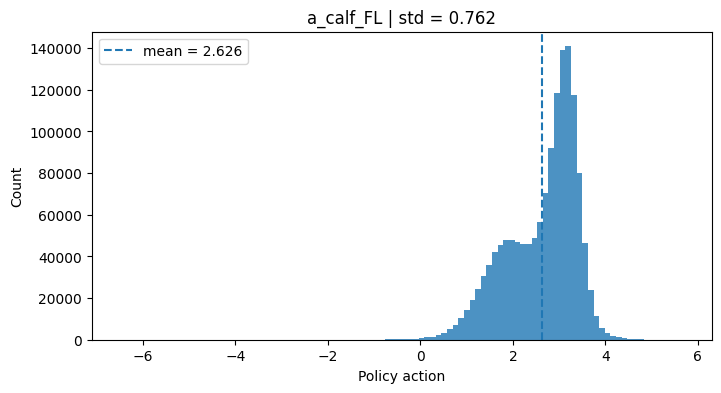

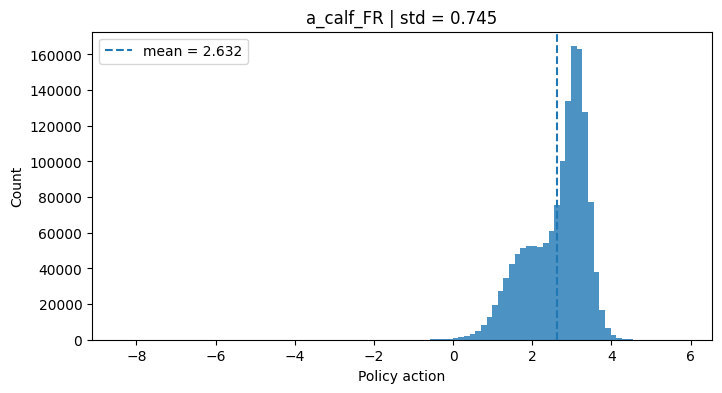

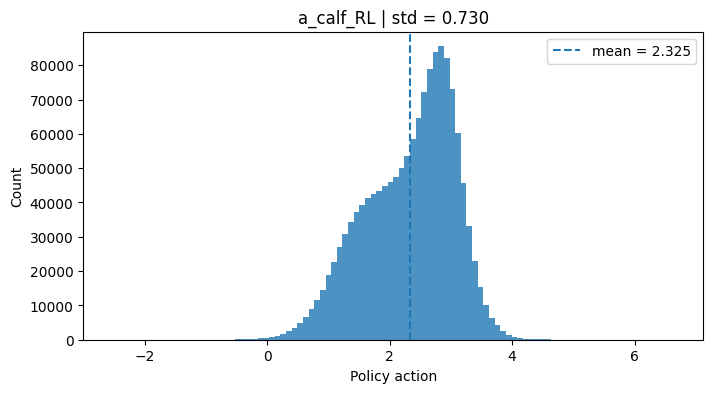

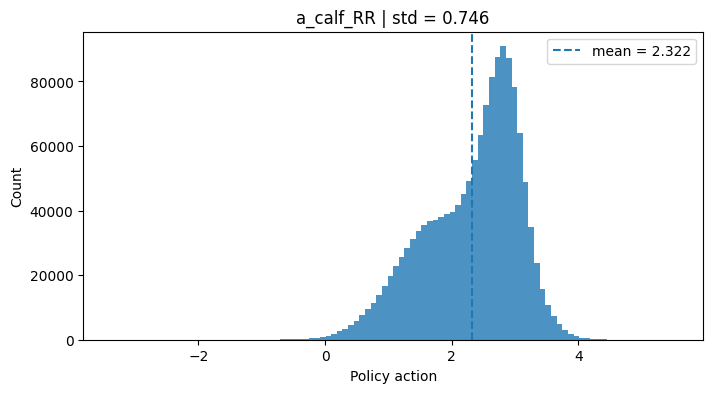

In [27]:
# --------------------------------------------------
# STEP 15. Action별 histogram
# --------------------------------------------------

for col in action_cols:

    plt.figure(figsize=(8, 4))

    plt.hist(
        A_all[col],
        bins=100,
        alpha=0.8
    )

    plt.axvline(
        A_all[col].mean(),
        linestyle="--",
        label=f"mean = {A_all[col].mean():.3f}"
    )

    plt.title(
        f"{col} | std = {A_all[col].std(ddof=0):.3f}"
    )

    plt.xlabel("Policy action")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

In [ ]:
# STEP 16. 학습 마지막 20% action 선택

TAIL_FRAC = 0.20

max_step = action["step"].max()

tail_start = max_step * (1 - TAIL_FRAC)

tail_mask = action["step"] >= tail_start

A_tail = action.loc[
    tail_mask,
    action_cols
].copy()

print("max step       :", max_step)
print("tail 시작 step :", action.loc[tail_mask, "step"].min())
print("tail rows      :", len(A_tail))
print("전체 대비      :", len(A_tail) / len(action))

max step       : 143999
tail 시작 step : 115200
tail rows      : 288000
전체 대비      : 0.2


In [29]:
action_std_compare = pd.DataFrame({
    "All": A_all.std(ddof=0),
    "Last 20%": A_tail.std(ddof=0),
})

display(action_std_compare)

,All,Last 20%
a_hip_FL,0.404165,0.371644
a_hip_FR,0.427693,0.393535
a_hip_RL,0.672251,0.894716
a_hip_RR,0.489886,0.522351
a_thigh_FL,0.559618,0.530904
a_thigh_FR,0.523662,0.517411
a_thigh_RL,0.841626,0.712141
a_thigh_RR,0.732142,0.743938
a_calf_FL,0.762413,0.727533
a_calf_FR,0.744783,0.712119


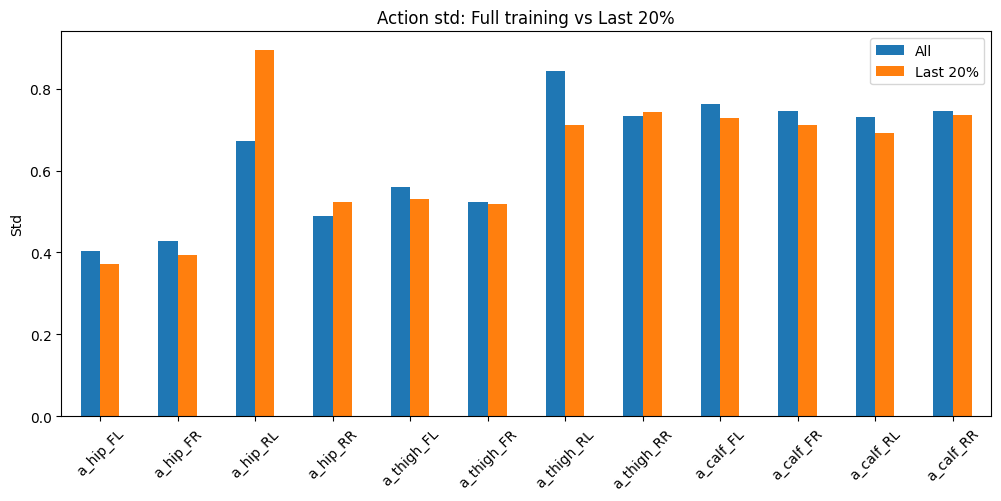

In [30]:
action_std_compare.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.ylabel("Std")
plt.title("Action std: Full training vs Last 20%")
plt.xticks(rotation=45)
plt.show()

In [ ]:
"""
CSV 로드
   ↓
데이터 크기 / column / 정렬 검사
   ↓
Velocity
   ├─ raw distribution
   ├─ reset 확인
   ├─ 축별 μ, σ
   ├─ pooled σ
   └─ normalization 후 MSE≈1 검증
   ↓
Splint Length
   ├─ normal L=0 제거
   ├─ histogram
   ├─ measured vs U[0.33,0.45]
   └─ normalization 후 MSE≈1 검증
   ↓
Action
   ├─ 관절별 distribution
   ├─ 전체 vs 마지막 20%
   ├─ exploration noise 확인
   ├─ Var(a)-σ_noise²
   ├─ deterministic teacher std
   └─ healthy / injured 비교
   ↓
최종 μ, σ 결정
"""